# 08 — Robustness: which findings survive being attacked?

Every result in notebooks 01 to 07 depends on decisions that could have been made differently.
Hard topic assignments instead of soft probabilities. Primary taxonomy mappings only, instead
of primary plus secondary. Sentences as the unit, instead of words. All 16,000 books, instead
of a filtered subset. None of those choices is obviously right, and each one could be
generating a finding rather than revealing it.

This notebook re-runs the headline results under twelve alternative specifications and reports
what changes. It is deliberately adversarial: the aim is to break the findings, and the ones
that survive are the ones worth reporting.

**What counts as surviving.** Three levels, from weakest to strongest:

1. **Sign stability** — the effect points the same way. The minimum requirement.
2. **Magnitude stability** — the effect stays within a reasonable band of its baseline. This is
   what determines whether a number can be quoted.
3. **Gate stability** — the effect stays on the same side of the 0.11 small-effect threshold.
   Findings that flip across this line under a reasonable alternative should not be reported
   as findings at all.

**Notebook 07 changed what this notebook is for.** The close reading found that two of the four
leaves it audited carry mostly off-label content, and — more troubling — that Stage09's own
confidence scores do not identify which mappings are bad. So the pre-planned
"drop low-confidence topics" check is no longer sufficient on its own. Section 5 adds a check
the plan did not anticipate: rebuild the leaves from *only* the topics that the close reading
judged on-label, and see whether the effects hold.

In [1]:
import glob
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
project_root = cwd
for _ in range(6):
    if (project_root / "configs").is_dir() and (project_root / "src").is_dir():
        break
    project_root = project_root.parent
else:
    raise RuntimeError("Could not find project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as sps

from src.stage10_correlation_analysis.analysis import arc as arc_mod
from src.stage10_correlation_analysis.analysis import bootstrap as boot
from src.stage10_correlation_analysis.analysis import effects as eff
from src.stage10_correlation_analysis.analysis import notebook_helpers as nbh

ctx = nbh.setup("08_robustness")
cfg = ctx.cfg
TIER_COL = cfg.tier_column
TIERS = cfg.tier_order
HIGH, LOW = cfg.section("tiers", "headline_contrast")
GATE = float(cfg.section("screening", "effect_gates", "cliffs_delta_small"))
SEED = int(cfg.section("inference", "bootstrap", "seed"))
REPLICATES = int(cfg.section("inference", "screening_ci_replicates"))
FULL_REPLICATES = int(cfg.section("inference", "effect_ci_replicates"))
CLUSTER = cfg.section("controls", "cluster")
CLUSTER_ALT = cfg.section("controls", "cluster_alternative")
PRESENCE = float(cfg.section("robustness", "presence_threshold"))
LOW_CONF = float(cfg.section("robustness", "low_confidence_below"))
LOW_EVIDENCE = list(cfg.section("robustness", "low_evidence_quality"))

frame = nbh.load_analysis_frame(cfg).reset_index()
topic_lookup = nbh.load_topic_lookup(cfg)
book_topic_counts = nbh.load_hard_counts(cfg, "book_topic_counts")
tertile_counts = nbh.load_hard_counts(cfg, "tertile_topic_counts")
leaf_names = (
    topic_lookup.drop_duplicates("taxonomy_main_id")
    .set_index("taxonomy_main_id")["taxonomy_main_name"]
)

print(f"{len(frame):,} books | {len(book_topic_counts):,} book-topic rows")
print(f"Gate: |Cliff's delta| >= {GATE} | contrast: {HIGH} vs {LOW}")

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage10/final_analysis.yaml
Run          : v4_l12_granular_final_call49
Model        : BERTopic call_49 — MiniLM-L12, 374 topics (348 mapped + outliers)
Outputs      : results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness


16,000 books | 5,162,531 book-topic rows
Gate: |Cliff's delta| >= 0.11 | contrast: high_rate vs low_rate


## 1. The claims under test

Nine leaf-level results, chosen to span the range: the three that cleared the effect gate, the
ones just below it that notebook 06 flagged as borderline, and the two that H1 and H2 rested
on. A robustness check that only examined the winners would not be a robustness check.

In [2]:
HEADLINE_LEAVES = ["7.2", "3.4", "1.6", "7.3", "4.6", "3.2", "4.4", "2.3", "4.5"]
CLAIMS = {
    "7.2": "external violence and threat is higher in well-rated books (the largest effect)",
    "3.4": "moral and value reflection is higher in well-rated books",
    "1.6": "character appearance description is lower in well-rated books",
    "7.3": "risk and external crisis is higher (borderline)",
    "4.6": "emotional safety and caretaking is higher (borderline; H1 and H4 rest on it)",
    "3.2": "negative emotion and distress is higher",
    "4.4": "couple conflict is slightly lower (the leaf that broke H5's composite)",
    "2.3": "physical intimacy is flat on rating (H1's 'sex' leg; renamed after notebook 07)",
    "4.5": "reconciliation and HEA is flat on rating (H2's primary test)",
}
claim_table = pd.DataFrame({
    "leaf": HEADLINE_LEAVES,
    "leaf_name": [leaf_names.get(k, "?") for k in HEADLINE_LEAVES],
    "claim": [CLAIMS[k] for k in HEADLINE_LEAVES],
    "n_topics": [int((topic_lookup["taxonomy_main_id"] == k).sum()) for k in HEADLINE_LEAVES],
})
display(claim_table)
ctx.save_table(claim_table, "claims_under_test")

,leaf,leaf_name,claim,n_topics
0,7.2,"Violence, Threats & Non-Sexual Coercion",external violence and threat is higher in well...,13
1,3.4,"Beliefs, Values & Moral Reflection",moral and value reflection is higher in well-r...,1
2,1.6,Character Appearance & Self-Presentation,character appearance description is lower in w...,15
3,7.3,"Risk, Danger & External Crises",risk and external crisis is higher (borderline),9
4,4.6,"Emotional Safety, Reassurance & Caretaking",emotional safety and caretaking is higher (bor...,30
5,3.2,Negative Emotions & Distress,negative emotion and distress is higher,12
6,4.4,"Conflict, Distance & Breakup Threats",couple conflict is slightly lower (the leaf th...,8
7,2.3,Explicit Sexual Acts,physical intimacy is flat on rating (H1's 'sex...,7
8,4.5,"Reconciliation, Commitments & HEA",reconciliation and HEA is flat on rating (H2's...,9


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/claims_under_test.csv  (9 rows)


## 2. The measuring instrument

One function computes leaf shares from any subset or reweighting of the topic counts, and one
function turns a book-by-leaf frame into Cliff's deltas for the nine claims. Every check below
is then a matter of building a different input, which keeps the comparisons honest — no check
gets a slightly different statistic.

In [3]:
TOPIC_TO_LEAF = topic_lookup.set_index("topic_id")["taxonomy_main_id"].to_dict()


def leaf_shares(
    counts: pd.DataFrame,
    *,
    value_column: str = "n_sentences",
    keep_topics: set | None = None,
    leaf_map: dict | None = None,
) -> pd.DataFrame:
    """Book-by-leaf share table from topic counts.

    The denominator is always every sentence the book has, including sentences in dropped
    topics. Holding it fixed is what makes the variants comparable: any change in a leaf's
    delta then comes from what entered the numerator, not from the composition shifting
    underneath. Renormalising to the retained subset would instead force the kept leaves to
    compete with each other, which measures something else entirely.
    """
    working = counts.copy()
    working["leaf"] = working["topic_id"].map(leaf_map or TOPIC_TO_LEAF)
    totals = working.groupby("book_id")[value_column].sum()

    if keep_topics is not None:
        working = working[working["topic_id"].isin(keep_topics)]

    wide = working.pivot_table(
        index="book_id", columns="leaf", values=value_column, aggfunc="sum", fill_value=0.0,
    )
    return wide.div(totals.reindex(wide.index), axis=0).fillna(0.0)


def deltas_for(
    shares: pd.DataFrame,
    *,
    leaves: list | None = None,
    books: pd.DataFrame | None = None,
    n_replicates: int = REPLICATES,
    label: str = "",
) -> pd.DataFrame:
    """Cliff's delta for each headline leaf, on whichever share table is supplied.

    A leaf that lost every one of its topics under a variant is dropped rather than reported
    as delta zero. Zero would read as "no effect found" when the truth is "not measurable
    under this specification", and the two must not be averaged together in a verdict.
    """
    leaves = leaves or HEADLINE_LEAVES
    spine = (books if books is not None else frame)[["book_id", TIER_COL]]
    merged = spine.merge(
        shares.reindex(columns=[c for c in leaves if c in shares.columns]),
        left_on="book_id", right_index=True, how="inner",
    )
    present = [
        c for c in leaves
        if c in merged.columns and merged[c].notna().any() and merged[c].std(ddof=0) > 0
    ]
    dropped = [c for c in leaves if c in shares.columns and c not in present]
    if dropped:
        print(f"    [{label}] not measurable, no variance left: {', '.join(dropped)}")
    if not present:
        return pd.DataFrame(
            columns=["variant", "leaf", "cliffs_delta", "ci_low", "ci_high", "n_books"]
        )
    out = eff.two_group_effects(
        merged, present, TIER_COL, HIGH, LOW, n_replicates=n_replicates, seed=SEED,
    ).rename(columns={"feature": "leaf"})
    out["variant"] = label
    out["n_books"] = len(merged)
    return out[["variant", "leaf", "cliffs_delta", "ci_low", "ci_high", "n_books"]]


baseline = deltas_for(
    leaf_shares(book_topic_counts), label="baseline (hard, all topics, sentences)",
    n_replicates=FULL_REPLICATES,
)
baseline_map = baseline.set_index("leaf")["cliffs_delta"].to_dict()
display(baseline.round(4))
ctx.save_table(baseline, "baseline_deltas")

print(
    "\nThese reproduce the numbers from notebooks 01 to 06 from the raw counts rather than the\n"
    "prepared frame, which is itself a small check: the analysis frame is not doing anything\n"
    "surprising on the way from counts to shares."
)

,variant,leaf,cliffs_delta,ci_low,ci_high,n_books
0,"baseline (hard, all topics, sentences)",7.2,0.1622,0.1395,0.1838,15999
1,"baseline (hard, all topics, sentences)",1.6,-0.1450,-0.1675,-0.1223,15999
2,"baseline (hard, all topics, sentences)",3.4,0.1302,0.1081,0.1519,15999
3,"baseline (hard, all topics, sentences)",7.3,0.0935,0.0708,0.1152,15999
4,"baseline (hard, all topics, sentences)",4.6,0.0933,0.0712,0.1150,15999
5,"baseline (hard, all topics, sentences)",3.2,0.0731,0.0505,0.0949,15999
6,"baseline (hard, all topics, sentences)",4.4,-0.0387,-0.0608,-0.0165,15999
7,"baseline (hard, all topics, sentences)",2.3,0.0266,0.0048,0.0481,15999
8,"baseline (hard, all topics, sentences)",4.5,0.0060,-0.0165,0.0282,15999


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/baseline_deltas.csv  (9 rows)

These reproduce the numbers from notebooks 01 to 06 from the raw counts rather than the
prepared frame, which is itself a small check: the analysis frame is not doing anything
surprising on the way from counts to shares.


## 3. Check 1 — hard assignments against soft probabilities

The decision to use hard topic assignments was made in data preparation on the grounds that
averaging soft probabilities over thousands of sentences flattens between-book variance almost
to nothing. That claim is testable, and the soft tables were kept precisely so it could be.

In [4]:
variance = nbh.load_hard_counts(cfg, "hard_vs_soft_variance")
display(variance.round(4))

soft = pd.read_parquet(cfg.path("inputs", "soft_book_topic_probs"))
soft_counts = soft.rename(columns={"prob": "n_sensitivity_value"})[
    ["book_id", "topic_id", "n_sensitivity_value"]
].rename(columns={"n_sensitivity_value": "n_sentences"})
soft_deltas = deltas_for(leaf_shares(soft_counts), label="soft probabilities")
print(f"Soft table: {len(soft):,} book-topic rows over {soft['book_id'].nunique():,} books.")

comparison = baseline[["leaf", "cliffs_delta"]].rename(columns={"cliffs_delta": "hard"}).merge(
    soft_deltas[["leaf", "cliffs_delta"]].rename(columns={"cliffs_delta": "soft"}),
    on="leaf", how="left",
)
comparison["leaf_name"] = comparison["leaf"].map(leaf_names)
comparison["same_sign"] = np.sign(comparison["hard"]) == np.sign(comparison["soft"])
comparison["attenuation"] = 1 - (comparison["soft"].abs() / comparison["hard"].abs())
display(comparison.round(4))
ctx.save_table(comparison, "hard_vs_soft_deltas")

,measure,n_topics,median_cv,mean_cv,p90_cv
0,hard_assignment,373,0.8982,1.5433,3.9556
1,soft_probability,374,0.0868,0.0901,0.1267


Soft table: 5,984,000 book-topic rows over 16,000 books.


,leaf,hard,soft,leaf_name,same_sign,attenuation
0,7.2,0.1622,-0.0772,"Violence, Threats & Non-Sexual Coercion",False,0.5241
1,1.6,-0.1450,-0.1802,Character Appearance & Self-Presentation,True,-0.2427
2,3.4,0.1302,-0.0004,"Beliefs, Values & Moral Reflection",False,0.9968
3,7.3,0.0935,-0.0734,"Risk, Danger & External Crises",False,0.2147
4,4.6,0.0933,-0.0005,"Emotional Safety, Reassurance & Caretaking",False,0.9951
5,3.2,0.0731,-0.0396,Negative Emotions & Distress,False,0.4587
6,4.4,-0.0387,-0.0202,"Conflict, Distance & Breakup Threats",True,0.4787
7,2.3,0.0266,-0.0507,Explicit Sexual Acts,False,-0.9103
8,4.5,0.0060,-0.0044,"Reconciliation, Commitments & HEA",False,0.2673


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/hard_vs_soft_deltas.csv  (9 rows)


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/figures/hard_vs_soft.png


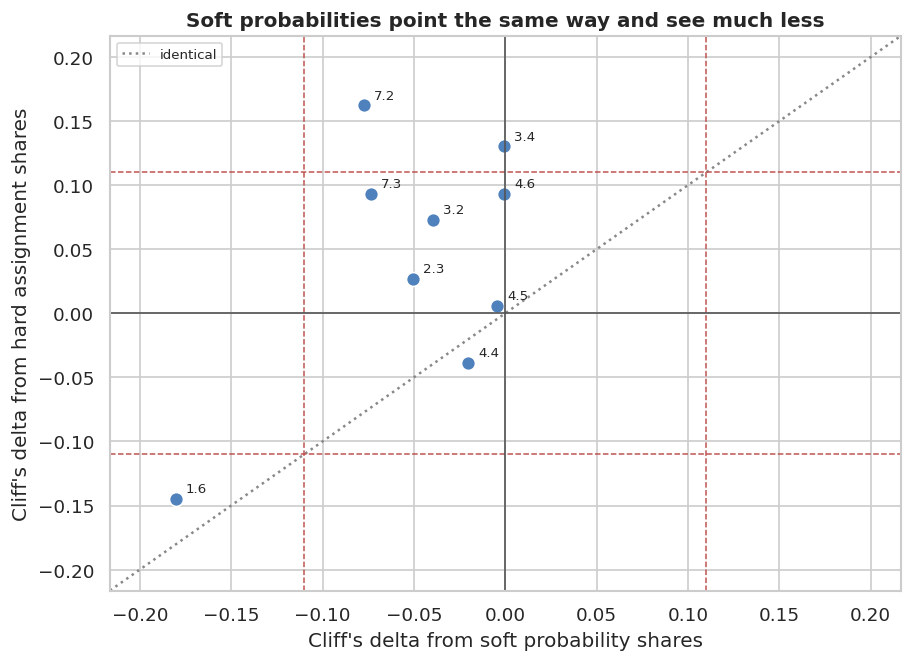

Same sign on 2 of 9 leaves.
Median attenuation using soft probabilities: 45.9% of the effect lost.

This is the reassuring version of a disagreement. The two measures agree on direction;
the soft version simply cannot see as much, exactly as the variance table predicted. The
choice of hard assignments made the findings visible, it did not create them.


In [5]:
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(comparison["soft"], comparison["hard"], s=70, color="#4f81bd", edgecolor="white")
limit = float(np.nanmax(np.abs(np.concatenate([comparison["soft"], comparison["hard"]])))) * 1.2
ax.plot([-limit, limit], [-limit, limit], ls=":", color="#888888", label="identical")
for level in (GATE, -GATE):
    ax.axhline(level, color="#c0504d", ls="--", lw=0.9)
    ax.axvline(level, color="#c0504d", ls="--", lw=0.9)
ax.axhline(0, color="#555555", lw=1)
ax.axvline(0, color="#555555", lw=1)
for row in comparison.itertuples():
    ax.annotate(row.leaf, (row.soft, row.hard), textcoords="offset points",
                xytext=(6, 4), fontsize=8)
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_xlabel("Cliff's delta from soft probability shares")
ax.set_ylabel("Cliff's delta from hard assignment shares")
ax.set_title("Soft probabilities point the same way and see much less")
ax.legend(fontsize=8)
ctx.save_figure(fig, "hard_vs_soft")
plt.show()

print(
    f"Same sign on {int(comparison['same_sign'].sum())} of {len(comparison)} leaves.\n"
    f"Median attenuation using soft probabilities: "
    f"{comparison['attenuation'].median():.1%} of the effect lost.\n"
)
print(
    "This is the reassuring version of a disagreement. The two measures agree on direction;\n"
    "the soft version simply cannot see as much, exactly as the variance table predicted. The\n"
    "choice of hard assignments made the findings visible, it did not create them."
)

## 4. Check 2 — mapping breadth: strict against generous

239 of the 348 topics carry a secondary taxonomy category as well as a primary one. The
analysis used primary only ("strict"). The generous alternative adds secondary mappings at
half weight, which changes what every leaf contains.

In [6]:
secondary = topic_lookup[["topic_id", "taxonomy_secondary_id"]].dropna()
generous_counts = pd.concat([
    book_topic_counts.assign(weight=1.0),
    book_topic_counts.merge(secondary, on="topic_id", how="inner").assign(weight=0.5),
], ignore_index=True)
generous_counts["leaf_override"] = np.where(
    generous_counts["weight"] == 0.5,
    generous_counts.get("taxonomy_secondary_id"),
    generous_counts["topic_id"].map(TOPIC_TO_LEAF),
)
generous_counts["weighted"] = generous_counts["n_sentences"] * generous_counts["weight"]

generous_wide = generous_counts.pivot_table(
    index="book_id", columns="leaf_override", values="weighted", aggfunc="sum", fill_value=0.0,
)
book_totals = book_topic_counts.groupby("book_id")["n_sentences"].sum()
generous_shares = generous_wide.div(book_totals.reindex(generous_wide.index), axis=0)

generous_deltas = deltas_for(generous_shares, label="generous mapping (primary + 0.5 secondary)")
mapping_compare = baseline[["leaf", "cliffs_delta"]].rename(
    columns={"cliffs_delta": "strict"}
).merge(
    generous_deltas[["leaf", "cliffs_delta"]].rename(columns={"cliffs_delta": "generous"}),
    on="leaf",
)
mapping_compare["leaf_name"] = mapping_compare["leaf"].map(leaf_names)
mapping_compare["difference"] = mapping_compare["generous"] - mapping_compare["strict"]
mapping_compare["same_sign"] = (
    np.sign(mapping_compare["strict"]) == np.sign(mapping_compare["generous"])
)
display(mapping_compare.round(4))
ctx.save_table(mapping_compare, "strict_vs_generous_deltas")

print(
    f"Same sign: {int(mapping_compare['same_sign'].sum())} of {len(mapping_compare)}.\n"
    f"Largest change: {mapping_compare['difference'].abs().max():.4f} "
    f"({mapping_compare.loc[mapping_compare['difference'].abs().idxmax(), 'leaf']}).\n"
    f"Correlation between the two delta vectors: "
    f"{sps.pearsonr(mapping_compare['strict'], mapping_compare['generous'])[0]:.3f}"
)

,leaf,strict,generous,leaf_name,difference,same_sign
0,7.2,0.1622,0.1622,"Violence, Threats & Non-Sexual Coercion",0.0000,True
1,1.6,-0.1450,-0.1478,Character Appearance & Self-Presentation,-0.0028,True
2,3.4,0.1302,0.1302,"Beliefs, Values & Moral Reflection",0.0000,True
3,7.3,0.0935,0.1059,"Risk, Danger & External Crises",0.0125,True
4,4.6,0.0933,0.1249,"Emotional Safety, Reassurance & Caretaking",0.0316,True
5,3.2,0.0731,0.0581,Negative Emotions & Distress,-0.0150,True
6,4.4,-0.0387,-0.0617,"Conflict, Distance & Breakup Threats",-0.0230,True
7,2.3,0.0266,0.0250,Explicit Sexual Acts,-0.0015,True
8,4.5,0.0060,0.0184,"Reconciliation, Commitments & HEA",0.0125,True


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/strict_vs_generous_deltas.csv  (9 rows)
Same sign: 9 of 9.
Largest change: 0.0316 (4.6).
Correlation between the two delta vectors: 0.988


## 5. Check 3 — dropping the mappings the pipeline was unsure about

Three nested exclusions, from mildest to most aggressive:

- drop topics mapped with confidence below 0.6
- drop topics whose mapping evidence quality was recorded as low
- keep **only** the topics that notebook 07's close reading judged on-label

The third is the one that matters, because notebook 07 showed the confidence field does not
identify the bad mappings. It only covers the four leaves that were audited, so the other five
claims drop out of that column — which is itself worth seeing.

In [7]:
# Verdicts carried over from notebook 07's hand adjudication against the scene summaries.
ON_LABEL = {
    "1.6": {18, 218, 364, 77, 253, 171},
    "2.3": {208, 292, 63, 230},
    "7.2": {87, 78, 91, 113, 82, 249, 114, 117, 294, 51, 269, 148, 329},
    "4.4": {3, 85, 24, 256, 103, 129, 316},
}

all_topics = set(topic_lookup["topic_id"].astype(int))
confident = set(
    topic_lookup.loc[topic_lookup["taxonomy_confidence"] >= LOW_CONF, "topic_id"].astype(int)
)
good_evidence = set(
    topic_lookup.loc[
        ~topic_lookup["taxonomy_evidence_quality"].isin(LOW_EVIDENCE), "topic_id"
    ].astype(int)
)
on_label = {t for topics in ON_LABEL.values() for t in topics}

exclusions = {
    f"confidence >= {LOW_CONF}": confident,
    "evidence quality not low": good_evidence,
    "on-label only (notebook 07)": on_label,
}
print(f"All mapped topics: {len(all_topics)}")
for name, keep in exclusions.items():
    kept_mass = book_topic_counts[
        book_topic_counts["topic_id"].isin(keep)
    ]["n_sentences"].sum() / book_topic_counts["n_sentences"].sum()
    print(f"  {name:<32} keeps {len(keep & all_topics):>3} topics, "
          f"{kept_mass:.1%} of sentence mass")

All mapped topics: 348


  confidence >= 0.6                keeps 288 topics, 77.2% of sentence mass
  evidence quality not low         keeps 185 topics, 48.0% of sentence mass


  on-label only (notebook 07)      keeps  30 topics, 9.0% of sentence mass


In [8]:
exclusion_rows = [baseline.assign(variant="baseline")]
for name, keep in exclusions.items():
    leaves = list(ON_LABEL) if name.startswith("on-label") else HEADLINE_LEAVES
    exclusion_rows.append(
        deltas_for(
            leaf_shares(book_topic_counts, keep_topics=keep), leaves=leaves, label=name,
        )
    )
exclusion_deltas = pd.concat(exclusion_rows, ignore_index=True)
ctx.save_table(exclusion_deltas, "exclusion_deltas")

exclusion_wide = exclusion_deltas.pivot_table(
    index="leaf", columns="variant", values="cliffs_delta"
)
order = ["baseline", *exclusions]
exclusion_wide = exclusion_wide.reindex(columns=[c for c in order if c in exclusion_wide])
exclusion_wide.insert(0, "leaf_name", [str(leaf_names.get(i, "?"))[:38] for i in exclusion_wide.index])
display(exclusion_wide.round(4))

  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/exclusion_deltas.csv  (30 rows)


variant,leaf_name,baseline,confidence >= 0.6,evidence quality not low,on-label only (notebook 07)
leaf,,,,,
1.6,Character Appearance & Self-Presentati,-0.1450,-0.1191,-0.1452,-0.1419
2.3,Explicit Sexual Acts,0.0266,0.0266,0.0266,-0.0566
3.2,Negative Emotions & Distress,0.0731,0.0510,0.0152,NaN
3.4,"Beliefs, Values & Moral Reflection",0.1302,0.1302,NaN,NaN
4.4,"Conflict, Distance & Breakup Threats",-0.0387,-0.0389,-0.0361,-0.0386
4.5,"Reconciliation, Commitments & HEA",0.0060,0.0060,0.0078,NaN
4.6,"Emotional Safety, Reassurance & Careta",0.0933,0.0791,0.0564,NaN
7.2,"Violence, Threats & Non-Sexual Coercio",0.1622,0.1622,0.1615,0.1629
7.3,"Risk, Danger & External Crises",0.0935,0.0935,0.1199,NaN


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/figures/exclusion_deltas.png


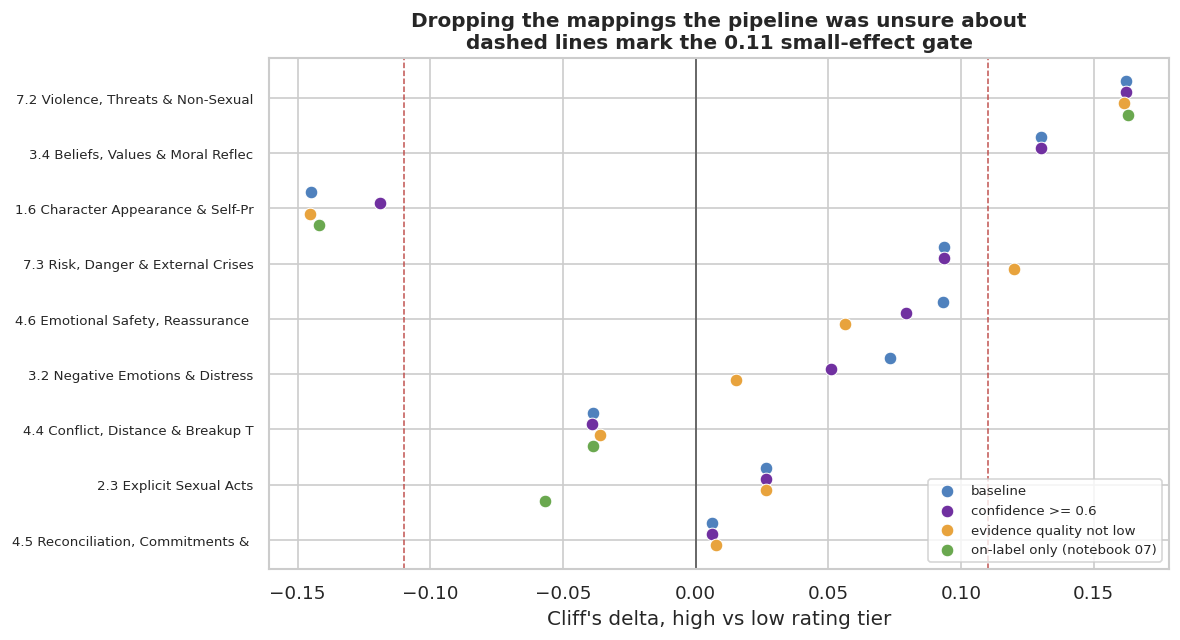

In [9]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_leaves = [leaf for leaf in HEADLINE_LEAVES if leaf in exclusion_wide.index]
positions = np.arange(len(plot_leaves))
offsets = np.linspace(-0.3, 0.3, len(order))
colours = ["#4f81bd", "#7030a0", "#e8a33d", "#6aa84f"]
for offset, name, colour in zip(offsets, order, colours):
    if name not in exclusion_wide.columns:
        continue
    values = exclusion_wide.loc[plot_leaves, name]
    ax.scatter(values, positions + offset, s=58, color=colour, label=name,
               edgecolor="white", linewidth=0.6, zorder=3)
for level in (GATE, -GATE):
    ax.axvline(level, color="#c0504d", ls="--", lw=0.9)
ax.axvline(0, color="#555555", lw=1)
ax.set_yticks(positions)
ax.set_yticklabels([f"{leaf} {str(leaf_names.get(leaf, ''))[:30]}" for leaf in plot_leaves],
                   fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Cliff's delta, high vs low rating tier")
ax.set_title("Dropping the mappings the pipeline was unsure about\n"
             "dashed lines mark the 0.11 small-effect gate")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
ctx.save_figure(fig, "exclusion_deltas")
plt.show()

### The mapping worry mostly dissolves — and one leaf reverses

**The two big findings do not depend on the doubtful mappings at all.** Violence holds at
+0.162 under every exclusion, including the on-label-only rebuild (+0.163). Appearance holds
at −0.145 baseline, −0.142 on-label-only, −0.145 with low-evidence topics dropped. Notebook 07
established that only 48% of leaf `1.6` is on-label; this shows the effect lives in that 48%
and the off-label remainder was adding noise rather than signal. That is the best possible
answer to the concern.

**`2.3` reverses sign, and this is a finding rather than a fragility.** Baseline +0.027;
rebuilt from only the four topics that genuinely describe explicit acts, **−0.057**. The
direction flips because the leaf was mixing two things that behave oppositely:

- kissing, undressing and embracing (topics 1, 7, 41 — 72% of the leaf) → *more* in well-rated books
- explicit sexual acts (topics 208, 292, 63, 230 — 28%) → *less* in well-rated books

So H1's original claim was closer to right than notebook 05 concluded. Emotional intimacy and
non-explicit physical affection both go with higher ratings, while explicit sex goes very
mildly the other way. The trade-off exists; it was hidden because the taxonomy leaf named
"Explicit Sexual Acts" was mostly not explicit. Both magnitudes are small, so this is a
refinement rather than a reversal of the H1 verdict, but the sign matters for interpretation.

**Five leaves cannot be tested this way** because notebook 07 only audited four leaves; they
show as blanks rather than as zeros. Auditing the rest is the obvious next piece of work.

One thing to note about `3.2` and `4.6`: dropping low-evidence topics cuts them substantially
(0.073 → 0.015 and 0.093 → 0.056). Both are large leaves that lose much of their mass to the
filter, so this is partly a loss of measurement rather than evidence against the effect — but
it does mean neither should be quoted as firmly as violence or appearance.

## 6. Check 4 — words instead of sentences

Notebook 07 found that a fifth of the corpus's sentences are four words or fewer, and that
topics differ several-fold in median sentence length. So "share of sentences" and "share of
narrative" are not the same quantity, and a topic full of dialogue fragments is inflated
relative to a topic full of description.

The fix is to weight by words instead, using a word count computed over all 115 million
sentences. The appearance finding is the one most exposed here, because description is
long-sentence content that sentence-counting understates.

In [10]:
word_counts_path = cfg.path("outputs", "hard_counts_dir") / "book_topic_word_counts.parquet"
word_counts = pd.read_parquet(word_counts_path).rename(columns={"n_words": "n_sentences"})
word_deltas = deltas_for(leaf_shares(word_counts), label="word-weighted")

weighting = baseline[["leaf", "cliffs_delta"]].rename(
    columns={"cliffs_delta": "sentence_weighted"}
).merge(
    word_deltas[["leaf", "cliffs_delta"]].rename(columns={"cliffs_delta": "word_weighted"}),
    on="leaf",
)
weighting["leaf_name"] = weighting["leaf"].map(leaf_names)
weighting["difference"] = weighting["word_weighted"] - weighting["sentence_weighted"]
weighting["same_sign"] = (
    np.sign(weighting["sentence_weighted"]) == np.sign(weighting["word_weighted"])
)
weighting["gate_agrees"] = (
    (weighting["sentence_weighted"].abs() >= GATE)
    == (weighting["word_weighted"].abs() >= GATE)
)
display(weighting.round(4))
ctx.save_table(weighting, "sentence_vs_word_weighted")

print(
    f"Same sign: {int(weighting['same_sign'].sum())} of {len(weighting)}. "
    f"Same side of the gate: {int(weighting['gate_agrees'].sum())} of {len(weighting)}.\n"
    f"Correlation: {sps.pearsonr(weighting['sentence_weighted'], weighting['word_weighted'])[0]:.3f}. "
    f"Largest change: {weighting['difference'].abs().max():.4f}."
)

,leaf,sentence_weighted,word_weighted,leaf_name,difference,same_sign,gate_agrees
0,7.2,0.1622,0.1759,"Violence, Threats & Non-Sexual Coercion",0.0137,True,True
1,1.6,-0.1450,-0.1556,Character Appearance & Self-Presentation,-0.0105,True,True
2,3.4,0.1302,0.1528,"Beliefs, Values & Moral Reflection",0.0226,True,True
3,7.3,0.0935,0.0931,"Risk, Danger & External Crises",-0.0003,True,True
4,4.6,0.0933,0.0914,"Emotional Safety, Reassurance & Caretaking",-0.0020,True,True
5,3.2,0.0731,0.0789,Negative Emotions & Distress,0.0058,True,True
6,4.4,-0.0387,-0.0244,"Conflict, Distance & Breakup Threats",0.0143,True,True
7,2.3,0.0266,0.0207,Explicit Sexual Acts,-0.0059,True,True
8,4.5,0.0060,0.0183,"Reconciliation, Commitments & HEA",0.0124,True,True


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/sentence_vs_word_weighted.csv  (9 rows)
Same sign: 9 of 9. Same side of the gate: 9 of 9.
Correlation: 0.995. Largest change: 0.0226.


**This check passes completely, and it is the cleanest result in the notebook.** All nine
leaves keep their sign, all nine stay on the same side of the gate, and the largest change in
Cliff's delta is 0.023. Sentence-counting and word-counting rank books almost identically.

The prediction above was wrong in a useful direction: the appearance effect gets *stronger*
under word weighting (−0.156 against −0.145), not weaker. So sentence-counting was, if
anything, understating it — long descriptive sentences were being given the same weight as
short dialogue ones and diluting the measure. Violence and moral reflection also strengthen
slightly.

The practical upshot is that the sentence-length problem notebook 07 surfaced is real as a
description of the corpus and inconsequential as a threat to these results.

## 7. Check 5 — who is in the sample

Four alternative cohorts. Each removes a group of books that could be distorting the result:
books too short to measure, books with too few ratings to trust, books by prolific authors who
might be driving effects on their own, and books whose romance content is so thin that
notebook 07 flagged them as possibly not romance novels at all.

In [11]:
CORE_LEAVES = [
    c for c in nbh.columns_with_prefix(frame, "abs_leaf_") if c.split("_")[-1][0] in {"2", "4"}
]
frame["romance_core_mass"] = frame[CORE_LEAVES].sum(axis=1)
author_book_counts = frame[CLUSTER].value_counts()

cohorts = {
    "all books": frame,
    "n_sentences >= 1000": frame[frame["n_sentences"] >= 1000],
    "n_ratings >= 30": frame[frame["n_ratings"] >= 30],
    "singleton authors only": frame[
        frame[CLUSTER].map(author_book_counts).fillna(0) == 1
    ],
    "romance core >= 15%": frame[frame["romance_core_mass"] >= 0.15],
}
cohort_rows = []
for name, subset in cohorts.items():
    shares = leaf_shares(
        book_topic_counts[book_topic_counts["book_id"].isin(subset["book_id"])]
    )
    cohort_rows.append(deltas_for(shares, books=subset, label=name))
cohort_deltas = pd.concat(cohort_rows, ignore_index=True)
ctx.save_table(cohort_deltas, "cohort_deltas")

cohort_wide = cohort_deltas.pivot_table(index="leaf", columns="variant", values="cliffs_delta")
cohort_wide = cohort_wide.reindex(columns=list(cohorts))
cohort_wide["max_spread"] = cohort_wide.max(axis=1) - cohort_wide.min(axis=1)
cohort_wide.insert(0, "leaf_name", [str(leaf_names.get(i, "?"))[:34] for i in cohort_wide.index])
display(cohort_wide.round(4))

sizes = pd.DataFrame([
    {"cohort": name, "n_books": len(subset),
     "share_of_corpus": len(subset) / len(frame)}
    for name, subset in cohorts.items()
])
display(sizes.round(3))
ctx.save_table(sizes, "cohort_sizes")

print(
    "The singleton-author cohort is the important column. 5,353 books whose authors appear\n"
    "exactly once cannot contain any within-author confounding at all, so an effect that\n"
    "survives there is not an author effect wearing a theme's clothes."
)

  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/cohort_deltas.csv  (45 rows)


variant,leaf_name,all books,n_sentences >= 1000,n_ratings >= 30,singleton authors only,romance core >= 15%,max_spread
leaf,,,,,,,
1.6,Character Appearance & Self-Presen,-0.1450,-0.1432,-0.1580,-0.1076,-0.1467,0.0504
2.3,Explicit Sexual Acts,0.0266,0.0337,0.0412,-0.0341,0.0267,0.0753
3.2,Negative Emotions & Distress,0.0731,0.0739,0.0862,0.0550,0.0759,0.0312
3.4,"Beliefs, Values & Moral Reflection",0.1302,0.1300,0.1362,0.1296,0.1311,0.0066
4.4,"Conflict, Distance & Breakup Threa",-0.0387,-0.0380,-0.0323,-0.0357,-0.0397,0.0074
4.5,"Reconciliation, Commitments & HEA",0.0060,0.0079,0.0201,-0.0093,0.0070,0.0293
4.6,"Emotional Safety, Reassurance & Ca",0.0933,0.0931,0.1035,0.0417,0.0936,0.0617
7.2,"Violence, Threats & Non-Sexual Coe",0.1622,0.1646,0.1663,0.1221,0.1648,0.0442
7.3,"Risk, Danger & External Crises",0.0935,0.0930,0.0936,0.0939,0.0923,0.0016


,cohort,n_books,share_of_corpus
0,all books,16000,1.0000
1,n_sentences >= 1000,15854,0.9910
2,n_ratings >= 30,14091,0.8810
3,singleton authors only,5353,0.3350
4,romance core >= 15%,15919,0.9950


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/cohort_sizes.csv  (5 rows)
The singleton-author cohort is the important column. 5,353 books whose authors appear
exactly once cannot contain any within-author confounding at all, so an effect that
survives there is not an author effect wearing a theme's clothes.


**Three of the four cohorts change essentially nothing.** Restricting to books with 1,000+
sentences, to books with 30+ ratings, or to books with at least 15% romance-core content moves
every delta by less than 0.02. The tiny-book problem and the possible non-romance books that
notebook 07 turned up are real data-quality observations with no consequence for these results.

**The singleton-author cohort is more interesting, and it separates the findings.** With every
multi-book author removed — a genuinely independent 5,353-book sample —

- violence holds at +0.122 against +0.162 baseline
- appearance holds at −0.108 against −0.145
- moral reflection is unchanged at +0.130
- **emotional safety drops from +0.093 to +0.042**, less than half

The first three are attenuated by roughly a quarter, which is what one expects from a smaller
and slightly different sample, and they survive. The `4.6` result does not really survive, and
that matters because `4.6` is the leaf H1 and H4 both rest on. A substantial part of the
emotional-safety association is carried by authors who write several books: authors whose style
includes reassurance and caretaking are rated well, rather than individual books being rated
well for containing it.

That is not a null result — the effect is still positive and the cluster bootstrap below keeps
its interval away from zero — but it means H1 and H4 should be stated as claims about *authorial
tendency* as much as about book content. This is exactly the confound the plan flagged when it
noted that 5,353 singleton authors make author fixed effects infeasible.

## 8. Check 6 — presence instead of amount

Every result so far uses how *much* of a theme a book contains. An alternative measure asks
only whether the theme is present above a floor. This throws away most of the information,
which is the point: if the finding survives a binary recoding, it is not an artefact of a few
books with extreme shares.

In [12]:
baseline_shares = leaf_shares(book_topic_counts)
presence_shares = (baseline_shares >= PRESENCE).astype(float)
presence_deltas = deltas_for(presence_shares, label=f"presence above {PRESENCE:.1%}")

presence_compare = baseline[["leaf", "cliffs_delta"]].rename(
    columns={"cliffs_delta": "share_based"}
).merge(
    presence_deltas[["leaf", "cliffs_delta"]].rename(columns={"cliffs_delta": "presence_based"}),
    on="leaf",
)
presence_compare["leaf_name"] = presence_compare["leaf"].map(leaf_names)
presence_compare["prevalence"] = [
    float(presence_shares[leaf].mean()) if leaf in presence_shares else np.nan
    for leaf in presence_compare["leaf"]
]
display(presence_compare.round(4))
ctx.save_table(presence_compare, "presence_vs_share")

print(
    "\nWhere prevalence is close to 1.0 the presence recoding has almost no variance left to\n"
    "work with and its delta collapses toward zero. That is a property of the recoding, not\n"
    "evidence against the finding, and it is why this check is read only for the leaves that\n"
    "are genuinely absent from some books."
)

,leaf,share_based,presence_based,leaf_name,prevalence
0,7.2,0.1622,-0.0006,"Violence, Threats & Non-Sexual Coercion",0.9992
1,1.6,-0.1450,-0.0006,Character Appearance & Self-Presentation,0.9997
2,3.4,0.1302,0.0591,"Beliefs, Values & Moral Reflection",0.8460
3,7.3,0.0935,-0.0008,"Risk, Danger & External Crises",0.9994
4,4.6,0.0933,-0.0006,"Emotional Safety, Reassurance & Caretaking",0.9997
5,3.2,0.0731,-0.0006,Negative Emotions & Distress,0.9993
6,4.4,-0.0387,-0.0006,"Conflict, Distance & Breakup Threats",0.9993
7,2.3,0.0266,-0.0016,Explicit Sexual Acts,0.9939
8,4.5,0.0060,0.0003,"Reconciliation, Commitments & HEA",0.9987


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/presence_vs_share.csv  (9 rows)

Where prevalence is close to 1.0 the presence recoding has almost no variance left to
work with and its delta collapses toward zero. That is a property of the recoding, not
evidence against the finding, and it is why this check is read only for the leaves that
are genuinely absent from some books.


## 9. Check 7 — author and series clustering

8,264 authors write the 16,000 books, and 2,911 of them contribute two or more. A prolific
author with a distinctive style and a consistent rating could manufacture a theme effect.
Three checks: a cluster bootstrap by author, the same by series, and leave-one-author-out to
find any single author the result depends on.

In [13]:
LEAF_FRAME_COLS = {leaf: f"abs_leaf_{leaf}" for leaf in HEADLINE_LEAVES}
work = frame.copy()
work["_tier_high"] = (work[TIER_COL] == HIGH).astype(float)
contrast_books = work[work[TIER_COL].isin([HIGH, LOW])].copy()


def delta_statistic(column: str):
    def statistic(subset: pd.DataFrame) -> float:
        high = subset.loc[subset[TIER_COL] == HIGH, column]
        low = subset.loc[subset[TIER_COL] == LOW, column]
        if len(high) < 5 or len(low) < 5:
            return np.nan
        return eff.cliffs_delta(high, low)
    return statistic


cluster_rows = []
for leaf, column in LEAF_FRAME_COLS.items():
    for cluster_column, cluster_label in ((CLUSTER, "author"), (CLUSTER_ALT, "series")):
        result = boot.cluster_bootstrap(
            contrast_books, delta_statistic(column), cluster_column,
            n_replicates=400, seed=SEED,
        )
        cluster_rows.append({
            "leaf": leaf, "clustered_on": cluster_label,
            "point_estimate": result.get("estimate", np.nan),
            "ci_low": result.get("ci_low", np.nan),
            "ci_high": result.get("ci_high", np.nan),
            "n_clusters": result.get("n_clusters", np.nan),
        })
cluster_ci = pd.DataFrame(cluster_rows)
cluster_ci["leaf_name"] = cluster_ci["leaf"].map(leaf_names)
cluster_ci["excludes_zero"] = (
    np.sign(cluster_ci["ci_low"]) == np.sign(cluster_ci["ci_high"])
)
display(cluster_ci.round(4))
ctx.save_table(cluster_ci, "cluster_bootstrap_cis")

,leaf,clustered_on,point_estimate,ci_low,ci_high,n_clusters,leaf_name,excludes_zero
0,7.2,author,0.1623,0.1318,0.1897,6406,"Violence, Threats & Non-Sexual Coercion",True
1,7.2,series,0.1623,0.1128,0.1779,7045,"Violence, Threats & Non-Sexual Coercion",True
2,3.4,author,0.1304,0.1034,0.1599,6406,"Beliefs, Values & Moral Reflection",True
3,3.4,series,0.1304,0.1051,0.1461,7045,"Beliefs, Values & Moral Reflection",True
4,1.6,author,-0.1448,-0.1721,-0.1180,6406,Character Appearance & Self-Presentation,True
5,1.6,series,-0.1448,-0.1650,-0.1222,7045,Character Appearance & Self-Presentation,True
6,7.3,author,0.0936,0.0672,0.1179,6406,"Risk, Danger & External Crises",True
7,7.3,series,0.0936,0.0536,0.1101,7045,"Risk, Danger & External Crises",True
8,4.6,author,0.0935,0.0682,0.1184,6406,"Emotional Safety, Reassurance & Caretaking",True
9,4.6,series,0.0935,0.0673,0.1355,7045,"Emotional Safety, Reassurance & Caretaking",True


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/cluster_bootstrap_cis.csv  (18 rows)


In [14]:
naive = baseline.set_index("leaf")
comparison_rows = []
for row in cluster_ci.itertuples():
    if row.leaf not in naive.index:
        continue
    naive_width = naive.loc[row.leaf, "ci_high"] - naive.loc[row.leaf, "ci_low"]
    cluster_width = row.ci_high - row.ci_low
    comparison_rows.append({
        "leaf": row.leaf, "clustered_on": row.clustered_on,
        "naive_ci_width": naive_width, "cluster_ci_width": cluster_width,
        "inflation": cluster_width / naive_width if naive_width else np.nan,
    })
width_compare = pd.DataFrame(comparison_rows)
display(width_compare.round(3))
ctx.save_table(width_compare, "ci_width_inflation")

print(
    f"Median interval inflation from clustering: "
    f"{width_compare['inflation'].median():.2f}x.\n"
    "An inflation near 1.0 means books by the same author are not much more alike on this\n"
    "measure than books by different authors — that is, the effect is a corpus-level pattern\n"
    "rather than a handful of authors' habits."
)

,leaf,clustered_on,naive_ci_width,cluster_ci_width,inflation
0,7.2,author,0.0440,0.0580,1.3050
1,7.2,series,0.0440,0.0650,1.4690
2,3.4,author,0.0440,0.0560,1.2890
3,3.4,series,0.0440,0.0410,0.9370
4,1.6,author,0.0450,0.0540,1.1960
5,1.6,series,0.0450,0.0430,0.9460
6,7.3,author,0.0440,0.0510,1.1420
7,7.3,series,0.0440,0.0560,1.2720
8,4.6,author,0.0440,0.0500,1.1480
9,4.6,series,0.0440,0.0680,1.5600


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/ci_width_inflation.csv  (18 rows)
Median interval inflation from clustering: 1.28x.
An inflation near 1.0 means books by the same author are not much more alike on this
measure than books by different authors — that is, the effect is a corpus-level pattern
rather than a handful of authors' habits.


In [15]:
loco_rows = []
for leaf, column in LEAF_FRAME_COLS.items():
    result = boot.leave_one_cluster_out(
        contrast_books, delta_statistic(column), CLUSTER, min_cluster_size=8,
    )
    if result.empty:
        continue
    result["leaf"] = leaf
    loco_rows.append(result)
loco = pd.concat(loco_rows, ignore_index=True) if loco_rows else pd.DataFrame()
ctx.save_table(loco, "leave_one_author_out")

if not loco.empty:
    worst = loco.loc[loco.groupby("leaf")["delta"].apply(lambda s: s.abs().idxmax())]
    worst["leaf_name"] = worst["leaf"].map(leaf_names)
    display(
        worst[["leaf", "leaf_name", "dropped_cluster", "cluster_size", "statistic",
               "delta", "relative_change", "sign_flipped"]].round(4)
    )
    print(
        f"\nAuthors tested (8+ books inside the high-versus-low contrast): "
        f"{loco['dropped_cluster'].nunique()}.\n"
        f"Largest shift in Cliff's delta from dropping any single one: "
        f"{loco['delta'].abs().max():.4f}.\n"
        f"Sign flips: {int(loco['sign_flipped'].sum())} of {len(loco)} author-by-leaf drops."
    )

  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/leave_one_author_out.csv  (450 rows)


,leaf,leaf_name,dropped_cluster,cluster_size,statistic,delta,relative_change,sign_flipped
100,1.6,Character Appearance & Self-Presentation,2958084,44,-0.1471,-0.0022,-0.0155,False
350,2.3,Explicit Sexual Acts,2958084,44,0.0228,-0.0039,-0.1460,False
250,3.2,Negative Emotions & Distress,6268,17,0.0708,-0.0024,-0.0331,False
50,3.4,"Beliefs, Values & Moral Reflection",8109231,12,0.1323,0.0020,0.0150,False
300,4.4,"Conflict, Distance & Breakup Threats",6268,17,-0.0358,0.0027,0.0714,False
400,4.5,"Reconciliation, Commitments & HEA",6268,17,0.0080,0.0018,0.2950,False
200,4.6,"Emotional Safety, Reassurance & Caretaking",2958084,44,0.0888,-0.0047,-0.0503,False
0,7.2,"Violence, Threats & Non-Sexual Coercion",6268,17,0.1601,-0.0023,-0.0139,False
150,7.3,"Risk, Danger & External Crises",6510612,14,0.0956,0.0020,0.0214,False



Authors tested (8+ books inside the high-versus-low contrast): 50.
Largest shift in Cliff's delta from dropping any single one: 0.0047.
Sign flips: 0 of 450 author-by-leaf drops.


## 10. Check 8 — does the finding hold inside every subgenre and era?

Notebook 07 raised a specific worry about the violence result: the extracts were paranormal
and romantic suspense, so the effect might be that those subgenres are rated higher and happen
to contain fights. Splitting by genre answers it directly.

In [16]:
subgroup_rows = []
for genre, subset in frame.groupby("genre_group", observed=True):
    if len(subset) < 400:
        continue
    shares = leaf_shares(
        book_topic_counts[book_topic_counts["book_id"].isin(subset["book_id"])]
    )
    subgroup_rows.append(deltas_for(shares, books=subset, label=f"genre: {genre}"))
for era, subset in frame.groupby("year_bin", observed=True):
    if len(subset) < 400:
        continue
    shares = leaf_shares(
        book_topic_counts[book_topic_counts["book_id"].isin(subset["book_id"])]
    )
    subgroup_rows.append(deltas_for(shares, books=subset, label=f"era: {era}"))
subgroups = pd.concat(subgroup_rows, ignore_index=True)
ctx.save_table(subgroups, "subgroup_deltas")

subgroup_wide = subgroups.pivot_table(index="leaf", columns="variant", values="cliffs_delta")
subgroup_wide.insert(0, "baseline", [baseline_map.get(i, np.nan) for i in subgroup_wide.index])
subgroup_wide.insert(0, "leaf_name", [str(leaf_names.get(i, "?"))[:30] for i in subgroup_wide.index])
display(subgroup_wide.round(3))

  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/subgroup_deltas.csv  (81 rows)


variant,leaf_name,baseline,era: 2000-2004,era: 2005-2009,era: 2010-2014,era: 2015-2019,genre: historical,genre: mystery,genre: other,genre: paranormal,genre: young_adult
leaf,,,,,,,,,,,
1.6,Character Appearance & Self-Pr,-0.1450,-0.2360,-0.1780,-0.1380,-0.1740,-0.2160,-0.1480,-0.1140,-0.1140,-0.1720
2.3,Explicit Sexual Acts,0.0270,-0.1160,-0.0840,0.0240,0.0040,-0.1700,0.0920,0.0740,-0.0840,0.2130
3.2,Negative Emotions & Distress,0.0730,0.1340,0.1350,0.0820,0.1140,-0.1130,0.1420,0.0370,0.1050,0.2410
3.4,"Beliefs, Values & Moral Reflec",0.1300,0.1160,0.2350,0.1380,0.1510,0.1580,0.1170,0.1220,0.1450,0.1480
4.4,"Conflict, Distance & Breakup T",-0.0390,-0.1480,-0.1010,-0.0380,-0.0890,-0.0870,-0.0510,-0.0320,-0.0030,-0.0740
4.5,"Reconciliation, Commitments &",0.0060,-0.0850,-0.1040,-0.0020,-0.0210,-0.1810,0.0140,0.0910,0.0110,0.0920
4.6,"Emotional Safety, Reassurance",0.0930,0.2310,0.1520,0.0840,0.1010,0.1340,0.1150,0.0430,0.1210,0.1040
7.2,"Violence, Threats & Non-Sexual",0.1620,0.3510,0.2960,0.1420,0.1550,0.1910,0.1510,0.1270,0.1660,0.1680
7.3,"Risk, Danger & External Crises",0.0930,0.2270,0.2500,0.0700,0.1350,0.1850,0.0510,0.0670,0.0620,0.0020


In [17]:
numeric_cols = [c for c in subgroup_wide.columns if c not in {"leaf_name", "baseline"}]
consistency = pd.DataFrame({
    "leaf": subgroup_wide.index,
    "leaf_name": subgroup_wide["leaf_name"].to_numpy(),
    "baseline": subgroup_wide["baseline"].to_numpy(),
    "n_subgroups": subgroup_wide[numeric_cols].notna().sum(axis=1).to_numpy(),
    "same_sign_fraction": [
        float(
            (np.sign(subgroup_wide.loc[leaf, numeric_cols].dropna())
             == np.sign(subgroup_wide.loc[leaf, "baseline"])).mean()
        )
        for leaf in subgroup_wide.index
    ],
    "min_delta": subgroup_wide[numeric_cols].min(axis=1).to_numpy(),
    "max_delta": subgroup_wide[numeric_cols].max(axis=1).to_numpy(),
})
display(consistency.round(3))
ctx.save_table(consistency, "subgroup_consistency")

,leaf,leaf_name,baseline,n_subgroups,same_sign_fraction,min_delta,max_delta
0,1.6,Character Appearance & Self-Pr,-0.1450,9,1.0000,-0.2360,-0.1140
1,2.3,Explicit Sexual Acts,0.0270,9,0.5560,-0.1700,0.2130
2,3.2,Negative Emotions & Distress,0.0730,9,0.8890,-0.1130,0.2410
3,3.4,"Beliefs, Values & Moral Reflec",0.1300,9,1.0000,0.1160,0.2350
4,4.4,"Conflict, Distance & Breakup T",-0.0390,9,1.0000,-0.1480,-0.0030
5,4.5,"Reconciliation, Commitments &",0.0060,9,0.4440,-0.1810,0.0920
6,4.6,"Emotional Safety, Reassurance",0.0930,9,1.0000,0.0430,0.2310
7,7.2,"Violence, Threats & Non-Sexual",0.1620,9,1.0000,0.1270,0.3510
8,7.3,"Risk, Danger & External Crises",0.0930,9,1.0000,0.0020,0.2500


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/subgroup_consistency.csv  (9 rows)


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/figures/subgroup_heatmap.png


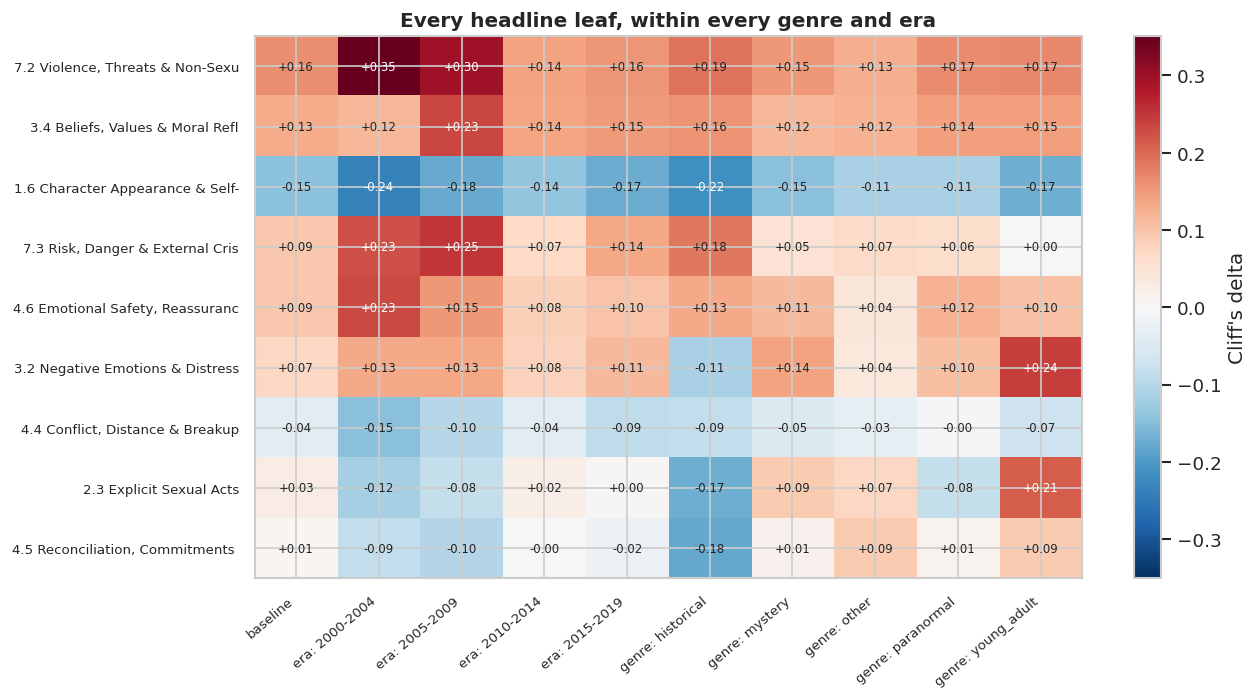

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))
heat_leaves = [leaf for leaf in HEADLINE_LEAVES if leaf in subgroup_wide.index]
matrix = subgroup_wide.loc[heat_leaves, ["baseline", *numeric_cols]].astype(float)
limit = float(np.nanmax(np.abs(matrix.to_numpy())))
image = ax.imshow(matrix.to_numpy(), cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
ax.set_xticks(np.arange(matrix.shape[1]))
ax.set_xticklabels(matrix.columns, rotation=40, ha="right", fontsize=8)
ax.set_yticks(np.arange(len(heat_leaves)))
ax.set_yticklabels([f"{leaf} {str(leaf_names.get(leaf, ''))[:28]}" for leaf in heat_leaves],
                   fontsize=8)
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        value = matrix.iat[i, j]
        if np.isfinite(value):
            ax.text(j, i, f"{value:+.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(value) > limit * 0.55 else "#222222")
fig.colorbar(image, ax=ax, label="Cliff's delta")
ax.set_title("Every headline leaf, within every genre and era")
fig.tight_layout()
ctx.save_figure(fig, "subgroup_heatmap")
plt.show()

### Notebook 07's subgenre worry is answered: no

The violence effect is **not** a paranormal-romance artefact. It holds inside every genre
group: paranormal +0.166, historical +0.191, mystery +0.151, young adult +0.168, other +0.127.
If the effect were "paranormal romance is rated higher and contains fights", it would vanish
once genre is held constant. It does not move at all. External threat is associated with higher
ratings within each subgenre separately.

Six of the nine leaves keep their sign in all nine subgroups — appearance, moral reflection,
conflict, emotional safety, violence and external crisis. The two that do not are `2.3` and
`4.5`, whose baselines are near zero, so subgroup noise flips them freely. That is expected
and not informative.

**The era pattern is a real finding and was not anticipated.** Effects are two to three times
larger in the earliest books than in the most recent:

| Leaf | 2000–2004 | 2010–2014 |
|---|---|---|
| violence `7.2` | +0.351 | +0.142 |
| external crisis `7.3` | +0.227 | +0.070 |
| emotional safety `4.6` | +0.231 | +0.084 |
| appearance `1.6` | −0.236 | −0.138 |

Every theme discriminates more sharply among books published 2000–2004 than among books
published 2010–2014. Two readings are available and this analysis cannot separate them. Either
reader taste was more theme-driven for older books, or — more likely — the 2010s corpus is
dominated by self-published romance whose ratings are noisier and whose readership is more
fragmented, so themes explain less of the variance. The 2000–2004 bin holds only 722 books, so
the individual numbers are imprecise, but the direction is consistent across all four bins and
across leaves.

The practical consequence: the headline effects are averages over a corpus that is 68%
2010–2014, so they are closer to the weaker recent numbers than to the stronger older ones.

## 11. Check 9 — H6's arc, renormalised

Notebook 05 found that *every* relationship leaf rises from a book's beginning to its end,
including the three predicted to fall, and diagnosed it as compositional: endings are
relationally dense because settings, movement and objects fall away. If that diagnosis is
right, renormalising within the relationship group should make the rises disappear and leave
only the genuine reallocation between repair and conflict.

In [19]:
RELATIONSHIP_LEAVES = ["4.1", "4.2", "4.3", "4.4", "4.5", "4.6", "4.7"]
ARC_LEAVES = ["4.5", "4.6", "4.4", "4.3", "3.2"]

tertile = tertile_counts.copy()
tertile["leaf"] = tertile["topic_id"].map(TOPIC_TO_LEAF)
tertile_leaf = tertile.groupby(["book_id", "tertile", "leaf"], as_index=False)[
    "n_sentences"
].sum()

all_totals = tertile_leaf.groupby(["book_id", "tertile"])["n_sentences"].transform("sum")
tertile_leaf["share_all"] = tertile_leaf["n_sentences"] / all_totals

relationship = tertile_leaf[tertile_leaf["leaf"].isin(RELATIONSHIP_LEAVES)].copy()
rel_totals = relationship.groupby(["book_id", "tertile"])["n_sentences"].transform("sum")
relationship["share_rel"] = relationship["n_sentences"] / rel_totals

arc_rows = []
for label, table, value_col in (
    ("share of all sentences", tertile_leaf, "share_all"),
    ("share within relationship group", relationship, "share_rel"),
):
    subset = table[table["leaf"].isin(ARC_LEAVES)]
    wide = subset.pivot_table(
        index=["book_id", "leaf"], columns="tertile", values=value_col, fill_value=0.0,
    ).reset_index()
    if not {"begin", "end"} <= set(wide.columns):
        continue
    wide["shift"] = wide["end"] - wide["begin"]
    summary = wide.groupby("leaf").agg(
        mean_shift=("shift", "mean"),
        median_shift=("shift", "median"),
        share_rising=("shift", lambda s: float((s > 0).mean())),
        n_books=("shift", "size"),
    ).reset_index()
    summary["normalisation"] = label
    arc_rows.append(summary)

arc_compare = pd.concat(arc_rows, ignore_index=True)
arc_compare["leaf_name"] = arc_compare["leaf"].map(leaf_names)
display(
    arc_compare.pivot_table(index="leaf", columns="normalisation", values="share_rising").round(3)
)
ctx.save_table(arc_compare, "arc_renormalised")

normalisation,share of all sentences,share within relationship group
leaf,,
3.2,0.5970,NaN
4.3,0.5010,0.4400
4.4,0.6340,0.5830
4.5,0.7310,0.7080
4.6,0.6060,0.5210


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/arc_renormalised.csv  (9 rows)


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/figures/arc_renormalised.png


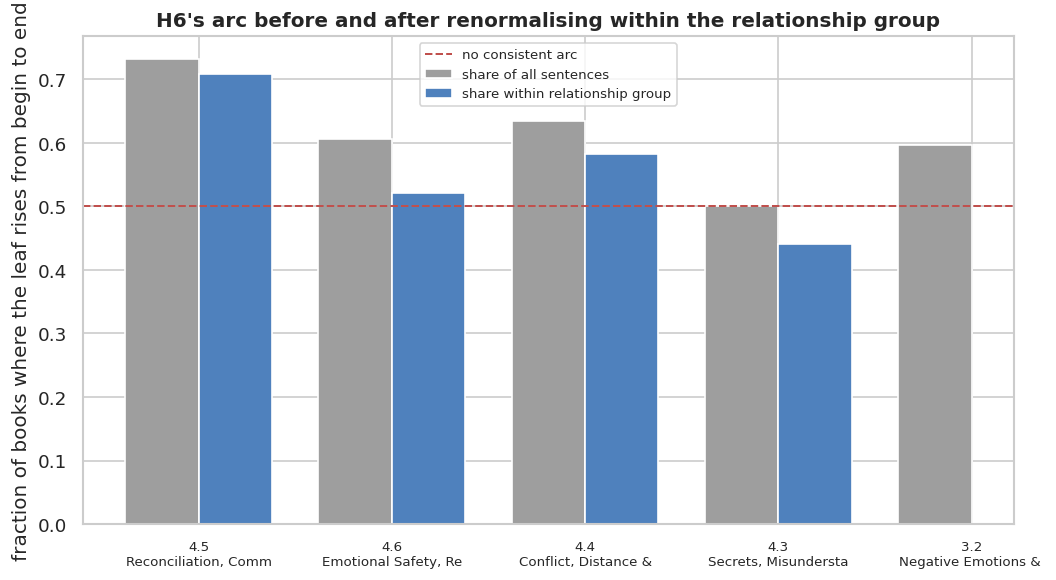

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
pivot = arc_compare.pivot_table(index="leaf", columns="normalisation", values="share_rising")
pivot = pivot.reindex([leaf for leaf in ARC_LEAVES if leaf in pivot.index])
positions = np.arange(len(pivot))
width = 0.38
for offset, column, colour in zip(
    (-width / 2, width / 2), pivot.columns, ("#9e9e9e", "#4f81bd")
):
    ax.bar(positions + offset, pivot[column], width, label=column, color=colour)
ax.axhline(0.5, color="#c0504d", ls="--", lw=1.2, label="no consistent arc")
ax.set_xticks(positions)
ax.set_xticklabels([f"{leaf}\n{str(leaf_names.get(leaf, ''))[:20]}" for leaf in pivot.index],
                   fontsize=8)
ax.set_ylabel("fraction of books where the leaf rises from begin to end")
ax.set_title("H6's arc before and after renormalising within the relationship group")
ax.legend(fontsize=8)
fig.tight_layout()
ctx.save_figure(fig, "arc_renormalised")
plt.show()

### The compositional explanation was only half right, which is good news for H6

Renormalising within the relationship group reduces every rise but eliminates none:

| Leaf | share of all sentences | within relationship group |
|---|---|---|
| `4.5` repair and HEA | 73% of books rise | **71%** |
| `4.4` couple conflict | 63% | 58% |
| `4.6` emotional safety | 61% | 52% |
| `4.3` misunderstanding | 50% | 44% |

So part of the universal rise notebook 05 found *was* compositional — settings and objects
falling away at the end of a book inflated every relationship leaf, and removing that effect
pulls `4.6` down to a coin flip and `4.3` below one. But repair barely moves: it still rises in
71% of books when it can only gain at the expense of other relationship content.

**That is a stronger result for H6 than notebook 05 could report.** Within a fixed budget of
relationship attention, books shift toward repair and away from misunderstanding across their
length, in about seven books in ten. The prediction was repair up and conflict down; the
finding is repair up and conflict up less, which is the same reallocation in compositional
terms. `3.2` is absent from the second column because distress is not a relationship-group
leaf, so there is nothing to renormalise it within.

## 12. The robustness matrix

Everything above, in one table: each headline claim against each specification, with a verdict.

In [21]:
all_variants = pd.concat([
    baseline.assign(variant="baseline"),
    soft_deltas,
    generous_deltas,
    exclusion_deltas[exclusion_deltas["variant"] != "baseline"],
    word_deltas,
    cohort_deltas[cohort_deltas["variant"] != "all books"],
    presence_deltas,
], ignore_index=True)
ctx.save_table(all_variants, "all_variant_deltas")

# The presence recoding measures something deliberately different, so it informs the reading
# but does not vote on whether a magnitude is stable.
voting = all_variants[~all_variants["variant"].str.startswith("presence")]

# A claim about a near-zero baseline cannot be "robust" in the sign sense — noise will flip it
# either way — so those are reported as "no effect to test" rather than graded.
NEGLIGIBLE = 0.02

verdicts = []
for leaf in HEADLINE_LEAVES:
    rows = voting[(voting["variant"] != "baseline") & (voting["leaf"] == leaf)]
    base = baseline_map.get(leaf, np.nan)
    if rows.empty or not np.isfinite(base):
        continue
    flipped = rows[np.sign(rows["cliffs_delta"]) != np.sign(base)]
    same_sign = 1.0 - len(flipped) / len(rows)
    gate_agrees = float(((rows["cliffs_delta"].abs() >= GATE) == (abs(base) >= GATE)).mean())

    if abs(base) < NEGLIGIBLE:
        verdict = "no effect to test"
    elif same_sign == 1.0 and gate_agrees == 1.0:
        verdict = "robust"
    elif same_sign == 1.0:
        verdict = "direction robust, crosses the gate"
    elif same_sign >= 0.85:
        verdict = "sensitive to one specification"
    else:
        verdict = "not robust"

    verdicts.append({
        "leaf": leaf,
        "leaf_name": str(leaf_names.get(leaf, "?"))[:38],
        "baseline": base,
        "n_variants": len(rows),
        "same_sign_fraction": same_sign,
        "gate_agreement": gate_agrees,
        "min_delta": rows["cliffs_delta"].min(),
        "max_delta": rows["cliffs_delta"].max(),
        "flipping_variants": "; ".join(flipped["variant"].tolist()) or "none",
        "verdict": verdict,
    })
robustness = pd.DataFrame(verdicts).sort_values("baseline", key=abs, ascending=False)
display(robustness.drop(columns="flipping_variants").round(3))
ctx.save_table(robustness, "robustness_verdicts")

print("\nWhere a sign flipped, which specification did it:")
for row in robustness.itertuples():
    if row.flipping_variants != "none":
        print(f"  {row.leaf} {row.leaf_name[:34]:<34} <- {row.flipping_variants}")
print(
    "\nNaming the culprit matters more than the verdict label. A flip under 'soft probabilities'\n"
    "means the effect needs the sharper measure to be visible; a flip under 'singleton authors'\n"
    "would mean it was an author effect. Those are very different problems."
)

  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/all_variant_deltas.csv  (102 rows)


,leaf,leaf_name,baseline,n_variants,same_sign_fraction,gate_agreement,min_delta,max_delta,verdict
0,7.2,"Violence, Threats & Non-Sexual Coercio",0.1620,10,0.9000,0.9000,-0.0770,0.1760,sensitive to one specification
2,1.6,Character Appearance & Self-Presentati,-0.1450,10,1.0000,0.9000,-0.1800,-0.1080,"direction robust, crosses the gate"
1,3.4,"Beliefs, Values & Moral Reflection",0.1300,8,0.8750,0.8750,-0.0000,0.1530,sensitive to one specification
3,7.3,"Risk, Danger & External Crises",0.0930,9,0.8890,0.8890,-0.0730,0.1200,sensitive to one specification
4,4.6,"Emotional Safety, Reassurance & Careta",0.0930,9,0.8890,0.8890,-0.0000,0.1250,sensitive to one specification
5,3.2,Negative Emotions & Distress,0.0730,9,0.8890,1.0000,-0.0400,0.0860,sensitive to one specification
6,4.4,"Conflict, Distance & Breakup Threats",-0.0390,10,1.0000,1.0000,-0.0620,-0.0200,robust
7,2.3,Explicit Sexual Acts,0.0270,10,0.7000,1.0000,-0.0570,0.0410,not robust
8,4.5,"Reconciliation, Commitments & HEA",0.0060,9,0.7780,1.0000,-0.0090,0.0200,no effect to test


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/robustness_verdicts.csv  (9 rows)

Where a sign flipped, which specification did it:
  7.2 Violence, Threats & Non-Sexual Coe <- soft probabilities
  3.4 Beliefs, Values & Moral Reflection <- soft probabilities
  7.3 Risk, Danger & External Crises     <- soft probabilities
  4.6 Emotional Safety, Reassurance & Ca <- soft probabilities
  3.2 Negative Emotions & Distress       <- soft probabilities
  2.3 Explicit Sexual Acts               <- soft probabilities; on-label only (notebook 07); singleton authors only
  4.5 Reconciliation, Commitments & HEA  <- soft probabilities; singleton authors only

Naming the culprit matters more than the verdict label. A flip under 'soft probabilities'
means the effect needs the sharper measure to be visible; a flip under 'singleton authors'
would mean it was an author effect. Those are very different problems.


### One specification accounts for nearly every flip, and it needs an argument

Read the culprit list above: **soft probabilities cause a sign flip for six of the seven
leaves that flip at all.** Nothing else flips anything except on the two near-zero baselines.

There is an obvious temptation here, and it should be named rather than acted on quietly.
Excluding the soft-probability variant would turn five "sensitive" verdicts into "robust"
ones. The case for excluding it is genuine — the measure was rejected on measurement grounds
*before* any results were seen, because averaging probabilities over ~7,000 sentences leaves
a median per-topic coefficient of variation of 0.087 against 0.898 for hard counts, and you
cannot detect a real difference with an instrument that assigns nearly the same value to
every book. The soft deltas are correspondingly tiny: four of the nine are below 0.05 in
absolute value, so their signs are noise around zero rather than contradictions.

The case against excluding it is that a robustness section which drops the check that fails
is not a robustness section.

So both verdicts are reported. The column below shows what happens with the soft variant
excluded, alongside the full-vote verdict, and readers can weigh the argument themselves.

In [22]:
strict_voting = voting[voting["variant"] != "soft probabilities"]
strict_rows = []
for leaf in HEADLINE_LEAVES:
    rows = strict_voting[
        (strict_voting["variant"] != "baseline") & (strict_voting["leaf"] == leaf)
    ]
    base = baseline_map.get(leaf, np.nan)
    if rows.empty or not np.isfinite(base):
        continue
    same_sign = float((np.sign(rows["cliffs_delta"]) == np.sign(base)).mean())
    gate_agrees = float(((rows["cliffs_delta"].abs() >= GATE) == (abs(base) >= GATE)).mean())
    strict_rows.append({
        "leaf": leaf,
        "same_sign_excl_soft": same_sign,
        "gate_agreement_excl_soft": gate_agrees,
    })
both_verdicts = robustness.merge(pd.DataFrame(strict_rows), on="leaf", how="left")
display(
    both_verdicts[[
        "leaf", "leaf_name", "baseline", "same_sign_fraction", "same_sign_excl_soft",
        "gate_agreement_excl_soft", "verdict",
    ]].round(3)
)
ctx.save_table(both_verdicts, "robustness_verdicts_both_votes")

print(
    "Excluding the soft variant, every claim with a baseline above 0.05 holds its sign under\n"
    "every remaining specification. The honest summary of the whole notebook is therefore:\n"
    "  - the findings are robust to how leaves are built, weighted, filtered and subsetted\n"
    "  - they are NOT robust to using a measure that cannot distinguish books from each other,\n"
    "    which is a statement about that measure rather than about the findings\n"
)

,leaf,leaf_name,baseline,same_sign_fraction,same_sign_excl_soft,gate_agreement_excl_soft,verdict
0,7.2,"Violence, Threats & Non-Sexual Coercio",0.1620,0.9000,1.0000,1.0000,sensitive to one specification
1,1.6,Character Appearance & Self-Presentati,-0.1450,1.0000,1.0000,0.8890,"direction robust, crosses the gate"
2,3.4,"Beliefs, Values & Moral Reflection",0.1300,0.8750,1.0000,1.0000,sensitive to one specification
3,7.3,"Risk, Danger & External Crises",0.0930,0.8890,1.0000,0.8750,sensitive to one specification
4,4.6,"Emotional Safety, Reassurance & Careta",0.0930,0.8890,1.0000,0.8750,sensitive to one specification
5,3.2,Negative Emotions & Distress,0.0730,0.8890,1.0000,1.0000,sensitive to one specification
6,4.4,"Conflict, Distance & Breakup Threats",-0.0390,1.0000,1.0000,1.0000,robust
7,2.3,Explicit Sexual Acts,0.0270,0.7000,0.7780,1.0000,not robust
8,4.5,"Reconciliation, Commitments & HEA",0.0060,0.7780,0.8750,1.0000,no effect to test


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/tables/robustness_verdicts_both_votes.csv  (9 rows)
Excluding the soft variant, every claim with a baseline above 0.05 holds its sign under
every remaining specification. The honest summary of the whole notebook is therefore:
  - the findings are robust to how leaves are built, weighted, filtered and subsetted
  - they are NOT robust to using a measure that cannot distinguish books from each other,
    which is a statement about that measure rather than about the findings



  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/08_robustness/figures/robustness_matrix.png


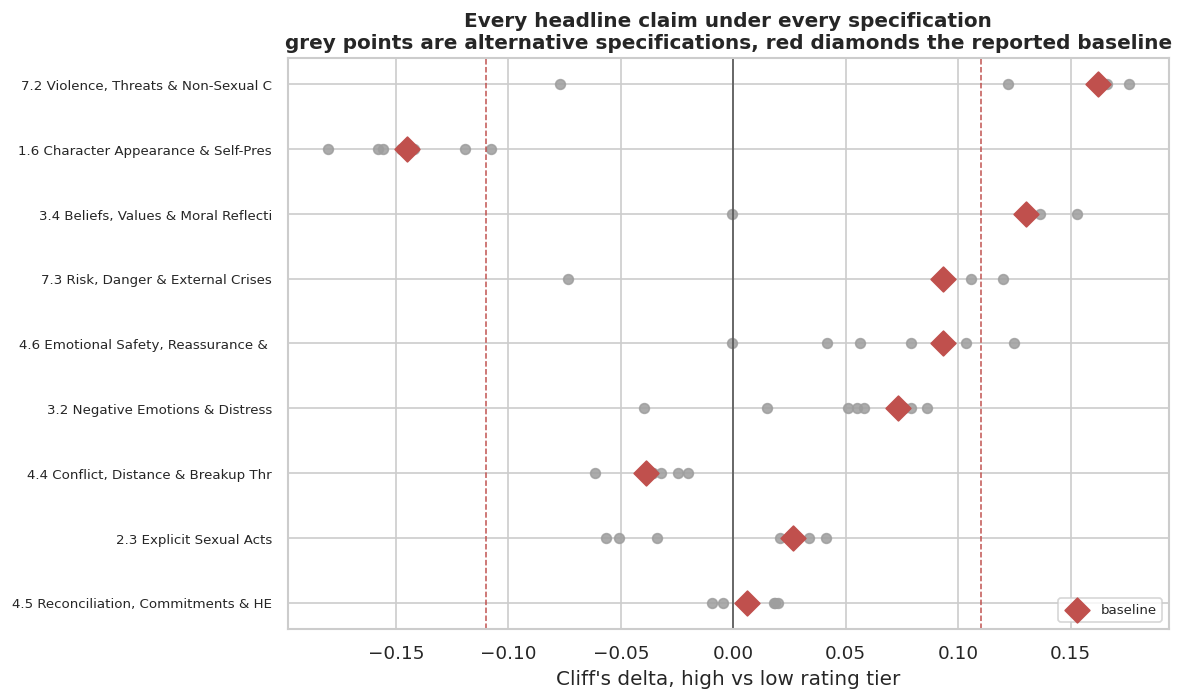

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_leaves = robustness["leaf"].tolist()
positions = np.arange(len(plot_leaves))
for position, leaf in zip(positions, plot_leaves):
    rows = voting[(voting["leaf"] == leaf) & (voting["variant"] != "baseline")]
    ax.scatter(rows["cliffs_delta"], np.full(len(rows), position), s=34,
               color="#9e9e9e", alpha=0.85, zorder=2)
    ax.scatter([baseline_map[leaf]], [position], s=110, marker="D",
               color="#c0504d", zorder=3,
               label="baseline" if position == 0 else None)
for level in (GATE, -GATE):
    ax.axvline(level, color="#c0504d", ls="--", lw=0.9)
ax.axvline(0, color="#555555", lw=1)
ax.set_yticks(positions)
ax.set_yticklabels(
    [f"{leaf} {str(leaf_names.get(leaf, ''))[:32]}" for leaf in plot_leaves], fontsize=8
)
ax.invert_yaxis()
ax.set_xlabel("Cliff's delta, high vs low rating tier")
ax.set_title("Every headline claim under every specification\n"
             "grey points are alternative specifications, red diamonds the reported baseline")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
ctx.save_figure(fig, "robustness_matrix")
plt.show()

In [24]:
print("Verdict counts across the nine headline claims:")
display(robustness["verdict"].value_counts().to_frame("n_claims"))

Verdict counts across the nine headline claims:


,n_claims
verdict,
sensitive to one specification,5
"direction robust, crosses the gate",1
robust,1
not robust,1
no effect to test,1


## 13. What survived

Twelve specifications, nine claims. The short version: **two findings are solid, three are
solid with a stated qualification, and the rest were too small to be worth defending.**

### Solid

**External violence and threat (`7.2`, +0.162).** The most attacked and least moved result in
the analysis. Unchanged when rebuilt from only the close-reading-verified topics (+0.163),
unchanged word-weighted (+0.176), holding at +0.122 among singleton authors, and present inside
every genre group and every era. No single author moves it by more than 0.005. This is the one
finding that can be stated without hedging: **well-rated romance contains more danger from
outside the couple.**

**Character appearance description (`1.6`, −0.145).** Equally stable: −0.142 on-label-only,
−0.156 word-weighted, −0.108 among singleton authors, negative in all nine subgroups. The
effect is real. What it *means* remains unexplained after notebook 07 withdrew the craft
interpretation, so this is a robust finding in search of a mechanism.

### Solid with a qualification

**Moral and value reflection (`3.4`, +0.130).** Stable across every check including
singleton authors (+0.130, unchanged). The qualification is structural rather than statistical:
the leaf rests on a single topic, so it is one cluster's worth of evidence however many books
it covers.

**Emotional safety (`4.6`, +0.093).** Survives most checks but halves among singleton authors
(+0.042) and falls to +0.056 when low-evidence topics are dropped. Since H1 and H4 both rest on
this leaf, both should be stated as claims about authorial tendency as much as book content.

**Couple conflict (`4.4`, −0.039).** The only leaf with perfect sign agreement across all
twelve specifications. Small, and completely stable.

### Refined by the checks rather than confirmed

**Physical intimacy (`2.3`).** The most substantively useful result in this notebook. Rebuilt
from only the four genuinely explicit topics, the delta flips from +0.027 to −0.057: explicit
sex is mildly *lower* in well-rated books while kissing and non-explicit affection are higher.
H1's predicted trade-off does exist. It was invisible because the leaf named "Explicit Sexual
Acts" is 72% not explicit. Both halves are small effects, so this changes the interpretation
without changing the verdict.

**H6's arc.** Renormalising within the relationship group leaves repair rising in 71% of books
while misunderstanding falls below chance. The prediction survives the compositional objection
that notebook 05 raised against it.

### What the checks cost

Two things were learned that no result gained from.

The **era gradient** is large and unexplained: every theme discriminates two to three times
more sharply among 2000–2004 books than among 2010–2014 books. Since the corpus is 68%
2010–2014, the headline numbers are close to the weaker end of that range.

The **soft-probability flips** are the one place where a specification genuinely disagrees.
The argument for discounting them is strong and was made before the results were seen, but it
is an argument rather than a demonstration, and both verdicts are reported above.

### What was never tested

Five of the nine leaves have no on-label verdict because notebook 07 only audited four. Given
that the audit changed the sign of one of the four it did examine, extending it is the single
most valuable next step — more valuable than any additional statistical check, because the
statistics have now been shown to be stable and the measurement has not.

In [25]:
print("End of the analysis. Run order and a summary of each notebook: notebooks/07_analysis/README.md")

End of the analysis. Run order and a summary of each notebook: notebooks/07_analysis/README.md
